# SHAP Encoder Importance (2021)

This notebook loads the trained orthogonal model and analyzes, for each 2021 race instance, how much the **driver encoder** and **constructor encoder** contribute to the prediction.

For every instance, contributions are normalized so that:

`driver_importance_norm + constructor_importance_norm = 1`

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import shap
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../"))

from train import build_graph, get_active_task, _build_instances_from_task
from models.pipeline_fusion import F1OrthogonalPipeline
import config as cfg

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

/data/antonioneves/ortogonal-representation/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
MODEL_NAME = "model_orthogonal"
MODEL_PATH = f"../output/models/{MODEL_NAME}.pth"
LATENT_DIM = 32
YEAR = 2021
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BACKGROUND_SIZE = 256
RANDOM_SEED = 42
MIN_POSITIVE_RACES = 5
TOP_K = 20

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# ---------------------------------------------------------------------------
# Load DB, instances and graph metadata
# ---------------------------------------------------------------------------
task, outcome_lookup = get_active_task()
db = task.dataset.get_db(upto_test_timestamp=False)

instances = _build_instances_from_task(task, outcome_lookup)
instances_2021 = instances[instances["year"] == YEAR].copy().reset_index(drop=True)
if instances_2021.empty:
    raise RuntimeError(f"No instances found for year={YEAR}")

print(f"Total instances: {len(instances)}")
print(f"Instances in {YEAR}: {len(instances_2021)}")

graph_data, node_to_col_names_dict, node_to_col_stats = build_graph(db)
num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}

# Keep a CPU copy for TensorFrame inputs.
graph_cpu = graph_data
graph_data = graph_data.to(DEVICE)

drivers_df = db.table_dict["drivers"].df.reset_index(drop=True)
constructors_df = db.table_dict["constructors"].df.reset_index(drop=True)
races_df = db.table_dict["races"].df.reset_index(drop=True)

race_id_to_name = races_df.set_index("raceId")["name"].to_dict()
driver_id_to_name = drivers_df.set_index("driverId").apply(
    lambda r: f"{r['forename']} {r['surname']}", axis=1
).to_dict()
constructor_id_to_name = constructors_df.set_index("constructorId")["name"].to_dict()

Loading Database object from /home/nvidia/.cache/relbench/rel-f1/db...
Done in 0.03 seconds.
Total instances: 9400
Instances in 2021: 440


In [4]:
# ---------------------------------------------------------------------------
# Load trained model (checkpoint-compatible load)
# ---------------------------------------------------------------------------
def load_compatible_model(path):
    model = F1OrthogonalPipeline(
        num_nodes_dict=num_nodes_dict,
        node_to_col_names_dict=node_to_col_names_dict,
        node_to_col_stats=node_to_col_stats,
        latent_dim=LATENT_DIM,
    ).to(DEVICE)

    # Materialize lazy params before compatibility checks.
    if model.encoder is not None:
        with torch.no_grad():
            x_init = model.encoder(graph_cpu.tf_dict)
            _ = model.graph_encoder(x_init, graph_data.edge_index_dict)

    ckpt = torch.load(path, map_location=DEVICE)
    state = model.state_dict()

    compatible = {}
    skipped = []
    for k, v in ckpt.items():
        if k in state and state[k].shape == v.shape:
            compatible[k] = v
        elif k in state:
            skipped.append((k, tuple(v.shape), tuple(state[k].shape)))

    missing, unexpected = model.load_state_dict(compatible, strict=False)
    print(f"Loaded tensors: {len(compatible)}")
    print(f"Skipped shape mismatch tensors: {len(skipped)}")
    print(f"Missing keys: {len(missing)}, Unexpected keys: {len(unexpected)}")

    model.eval()
    return model

model = load_compatible_model(MODEL_PATH)

Loaded tensors: 471
Skipped shape mismatch tensors: 4
Missing keys: 4, Unexpected keys: 0


In [5]:
# ---------------------------------------------------------------------------
# Compute per-instance latent vectors and predictions for 2021
# ---------------------------------------------------------------------------
with torch.no_grad():
    driver_ids = torch.tensor(instances_2021["driverId"].values, dtype=torch.long, device=DEVICE)
    constructor_ids = torch.tensor(instances_2021["constructorId"].values, dtype=torch.long, device=DEVICE)

    logits, _, _, v_driver, v_constructor, _ = model(
        graph_x_dict=None,
        graph_edge_index_dict=graph_data.edge_index_dict,
        target_constructor_ids=constructor_ids,
        target_driver_ids=driver_ids,
        graph_tf_dict=graph_cpu.tf_dict,
    )

    probs = torch.sigmoid(logits.squeeze(-1)).detach().cpu().numpy()
    v_driver_np = v_driver.detach().cpu().numpy()
    v_constructor_np = v_constructor.detach().cpu().numpy()

fused_np = np.concatenate([v_driver_np, v_constructor_np], axis=1)
fused_tensor = torch.tensor(fused_np, dtype=torch.float32, device=DEVICE)

print(f"Latent shape driver: {v_driver_np.shape}")
print(f"Latent shape constructor: {v_constructor_np.shape}")
print(f"Fused shape: {fused_np.shape}")

Latent shape driver: (440, 32)
Latent shape constructor: (440, 32)
Fused shape: (440, 64)


In [6]:
# ---------------------------------------------------------------------------
# SHAP over fused latent space: signed effects + normalized magnitude split
# ---------------------------------------------------------------------------
class HeadOnlyModel(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.classifier = classifier

    def forward(self, x):
        return self.classifier(x)

head_model = HeadOnlyModel(model.classifier).to(DEVICE)
head_model.eval()

bg_size = min(BACKGROUND_SIZE, fused_tensor.shape[0])
bg_idx = np.random.choice(fused_tensor.shape[0], size=bg_size, replace=False)
background = fused_tensor[bg_idx]

explainer = shap.GradientExplainer(head_model, background)
shap_values = explainer.shap_values(fused_tensor)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

# Base logit for additivity checks: use mean head output on background.
# This is robust across SHAP versions where GradientExplainer may not expose
# expected_value as an attribute.
with torch.no_grad():
    base_logit = float(head_model(background).mean().detach().cpu().item())

# Signed effects preserve whether each encoder pushes prediction up or down.
driver_signed = shap_values[:, :LATENT_DIM].sum(axis=1)
constructor_signed = shap_values[:, LATENT_DIM:].sum(axis=1)

# Keep absolute normalized split for magnitude-only comparison.
shap_abs = np.abs(shap_values)
driver_raw = shap_abs[:, :LATENT_DIM].sum(axis=1)
constructor_raw = shap_abs[:, LATENT_DIM:].sum(axis=1)

den = driver_raw + constructor_raw + 1e-12
driver_norm = driver_raw / den
constructor_norm = constructor_raw / den

# Logit reconstruction and probability-space directional deltas.
model_logits = logits.squeeze(-1).detach().cpu().numpy()
logit_from_shap = base_logit + driver_signed + constructor_signed
sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))

prob_from_shap = sigmoid(logit_from_shap)
driver_delta_prob = prob_from_shap - sigmoid(base_logit + constructor_signed)
constructor_delta_prob = prob_from_shap - sigmoid(base_logit + driver_signed)

importance_check = np.max(np.abs((driver_norm + constructor_norm) - 1.0))
additivity_mae = np.mean(np.abs(logit_from_shap - model_logits))
prob_reconstruction_mae = np.mean(np.abs(prob_from_shap - probs))

print(f"Max normalization error (should be ~0): {importance_check:.2e}")
print(f"Logit additivity MAE (SHAP vs model): {additivity_mae:.2e}")
print(f"Probability reconstruction MAE: {prob_reconstruction_mae:.2e}")

Max normalization error (should be ~0): 1.18e-12
Logit additivity MAE (SHAP vs model): 1.39e-01
Probability reconstruction MAE: 1.66e-02


In [7]:
# ---------------------------------------------------------------------------
# Build analysis tables with both signed and magnitude metrics
# ---------------------------------------------------------------------------
analysis_df = instances_2021.copy()
analysis_df["prediction_prob_top3"] = probs
analysis_df["prediction_prob_from_shap"] = prob_from_shap
analysis_df["driver_importance_raw"] = driver_raw
analysis_df["constructor_importance_raw"] = constructor_raw
analysis_df["driver_importance_norm"] = driver_norm
analysis_df["constructor_importance_norm"] = constructor_norm
analysis_df["driver_signed"] = driver_signed
analysis_df["constructor_signed"] = constructor_signed
analysis_df["driver_delta_prob"] = driver_delta_prob
analysis_df["constructor_delta_prob"] = constructor_delta_prob
analysis_df["base_logit"] = base_logit
analysis_df["model_logit"] = model_logits
analysis_df["logit_from_shap"] = logit_from_shap

analysis_df["driver_name"] = analysis_df["driverId"].map(driver_id_to_name)
analysis_df["constructor_name"] = analysis_df["constructorId"].map(constructor_id_to_name)
analysis_df["race_name"] = analysis_df["raceId"].map(race_id_to_name)

# Global per-driver summary (direction + magnitude).
per_driver = (
    analysis_df
    .groupby(["driverId", "driver_name"], as_index=False)
    .agg(
        races=("raceId", "count"),
        mean_prediction_prob_top3=("prediction_prob_top3", "mean"),
        mean_driver_importance=("driver_importance_norm", "mean"),
        mean_constructor_importance=("constructor_importance_norm", "mean"),
        mean_driver_signed=("driver_signed", "mean"),
        mean_constructor_signed=("constructor_signed", "mean"),
        mean_driver_delta_prob=("driver_delta_prob", "mean"),
        mean_constructor_delta_prob=("constructor_delta_prob", "mean"),
    )
)

# Complementary per-team summary.
per_constructor = (
    analysis_df
    .groupby(["constructorId", "constructor_name"], as_index=False)
    .agg(
        races=("raceId", "count"),
        mean_prediction_prob_top3=("prediction_prob_top3", "mean"),
        mean_driver_importance=("driver_importance_norm", "mean"),
        mean_constructor_importance=("constructor_importance_norm", "mean"),
        mean_driver_signed=("driver_signed", "mean"),
        mean_constructor_signed=("constructor_signed", "mean"),
        mean_driver_delta_prob=("driver_delta_prob", "mean"),
        mean_constructor_delta_prob=("constructor_delta_prob", "mean"),
    )
)

# Positive-only subset: top3 == 1 means beneficial outcomes.
positive_df = analysis_df[analysis_df["top3"] == 1].copy()

per_driver_positive = (
    positive_df
    .groupby(["driverId", "driver_name"], as_index=False)
    .agg(
        positive_races=("raceId", "count"),
        mean_prediction_prob_top3_positive=("prediction_prob_top3", "mean"),
        mean_driver_importance_positive=("driver_importance_norm", "mean"),
        std_driver_importance_positive=("driver_importance_norm", "std"),
        mean_constructor_importance_positive=("constructor_importance_norm", "mean"),
        total_driver_importance_positive=("driver_importance_norm", "sum"),
        total_constructor_importance_positive=("constructor_importance_norm", "sum"),
        mean_driver_signed_positive=("driver_signed", "mean"),
        mean_constructor_signed_positive=("constructor_signed", "mean"),
        mean_driver_delta_prob_positive=("driver_delta_prob", "mean"),
        mean_constructor_delta_prob_positive=("constructor_delta_prob", "mean"),
    )
)

# Apply minimum positive-race filter selected for ranking stability.
per_driver_positive = per_driver_positive[
    per_driver_positive["positive_races"] >= MIN_POSITIVE_RACES
].copy()

# 95% CI for split point on positive-only samples.
per_driver_positive["std_driver_importance_positive"] = per_driver_positive[
    "std_driver_importance_positive"
].fillna(0.0)
per_driver_positive["driver_ci95_positive"] = (
    1.96
    * per_driver_positive["std_driver_importance_positive"]
    / np.sqrt(per_driver_positive["positive_races"].clip(lower=1))
)
per_driver_positive["driver_ci95_low_positive"] = (
    per_driver_positive["mean_driver_importance_positive"]
    - per_driver_positive["driver_ci95_positive"]
).clip(0, 1)
per_driver_positive["driver_ci95_high_positive"] = (
    per_driver_positive["mean_driver_importance_positive"]
    + per_driver_positive["driver_ci95_positive"]
).clip(0, 1)

per_driver_positive["driver_minus_constructor_positive"] = (
    per_driver_positive["mean_driver_importance_positive"]
    - per_driver_positive["mean_constructor_importance_positive"]
)

# Sanity check for normalized split in the positive-only ranking table.
positive_norm_gap = (
    per_driver_positive["mean_driver_importance_positive"]
    + per_driver_positive["mean_constructor_importance_positive"]
    - 1.0
).abs().max()
print(f"Positive-only rows: {len(positive_df)}")
print(f"Drivers kept with at least {MIN_POSITIVE_RACES} positive races: {len(per_driver_positive)}")
print(f"Max positive-only normalization gap: {positive_norm_gap:.2e}")

# Keep the legacy ranking for continuity with existing plots.
rank_driver_positive = per_driver_positive.sort_values(
    ["mean_driver_importance_positive", "positive_races"], ascending=[False, False]
).reset_index(drop=True)

# New sign-aware rankings.
rank_driver_signed_positive = per_driver.sort_values(
    ["mean_driver_signed", "races"], ascending=[False, False]
).reset_index(drop=True)
rank_driver_signed_negative = per_driver.sort_values(
    ["mean_driver_signed", "races"], ascending=[True, False]
).reset_index(drop=True)
rank_constructor_signed_positive = per_constructor.sort_values(
    ["mean_constructor_signed", "races"], ascending=[False, False]
).reset_index(drop=True)
rank_constructor_signed_negative = per_constructor.sort_values(
    ["mean_constructor_signed", "races"], ascending=[True, False]
).reset_index(drop=True)

print("Top positive-only drivers by DRIVER encoder importance (magnitude split):")
display(rank_driver_positive.head(TOP_K))
print("Top drivers by signed driver effect (helpful):")
display(rank_driver_signed_positive.head(10))
print("Top drivers by signed driver effect (harmful):")
display(rank_driver_signed_negative.head(10))

Positive-only rows: 66
Drivers kept with at least 5 positive races: 4
Max positive-only normalization gap: 4.33e-13
Top positive-only drivers by DRIVER encoder importance (magnitude split):


,driverId,driver_name,positive_races,mean_prediction_prob_top3_positive,mean_driver_importance_positive,std_driver_importance_positive,mean_constructor_importance_positive,total_driver_importance_positive,total_constructor_importance_positive,mean_driver_signed_positive,mean_constructor_signed_positive,mean_driver_delta_prob_positive,mean_constructor_delta_prob_positive,driver_ci95_positive,driver_ci95_low_positive,driver_ci95_high_positive,driver_minus_constructor_positive
0,0,Lewis Hamilton,17,0.526051,0.489225,0.009228,0.510775,8.316820,8.683180,1.520393,1.534277,0.332245,0.334826,0.004387,0.484838,0.493611,-0.021551
1,829,Max Verstappen,18,0.459262,0.406809,0.012284,0.593191,7.322561,10.677439,1.059639,1.667529,0.229665,0.317662,0.005675,0.401134,0.412484,-0.186382
2,821,Valtteri Bottas,11,0.487717,0.356249,0.012692,0.643751,3.918740,7.081260,1.028177,1.856931,0.234185,0.360418,0.007501,0.348748,0.363750,-0.287502
3,814,Sergio Pérez,5,0.325442,0.140510,0.008883,0.859490,0.702549,4.297451,0.247544,1.926965,0.051530,0.257690,0.007787,0.132723,0.148296,-0.718980


Top drivers by signed driver effect (helpful):


,driverId,driver_name,races,mean_prediction_prob_top3,mean_driver_importance,mean_constructor_importance,mean_driver_signed,mean_constructor_signed,mean_driver_delta_prob,mean_constructor_delta_prob
0,19,Sebastian Vettel,22,0.260453,0.795960,0.204040,2.239444,-0.322980,0.232308,-0.066987
1,3,Fernando Alonso,22,0.182135,0.807560,0.192440,1.540210,-0.156923,0.133967,-0.023296
2,0,Lewis Hamilton,22,0.526051,0.489331,0.510669,1.503922,1.517523,0.326869,0.329278
3,7,Kimi Räikkönen,20,0.040515,0.454119,0.545881,1.396845,-1.666584,0.029937,-0.139764
4,829,Max Verstappen,22,0.459262,0.405032,0.594968,1.044595,1.657465,0.225244,0.313238
5,821,Valtteri Bottas,22,0.487717,0.353837,0.646163,1.008446,1.841243,0.228398,0.353805
6,842,Charles Leclerc,22,0.453661,0.278157,0.721843,0.681337,2.091753,0.159075,0.367593
7,816,Daniel Ricciardo,22,0.298375,0.327218,0.672782,0.658377,1.393856,0.117730,0.202395
8,844,Lando Norris,22,0.288398,0.327453,0.672547,0.613057,1.379455,0.107708,0.194064
9,814,Sergio Pérez,22,0.325442,0.150415,0.849585,0.269235,1.917376,0.056604,0.260010


Top drivers by signed driver effect (harmful):


,driverId,driver_name,races,mean_prediction_prob_top3,mean_driver_importance,mean_constructor_importance,mean_driver_signed,mean_constructor_signed,mean_driver_delta_prob,mean_constructor_delta_prob
0,851,Nikita Mazepin,22,0.001252,0.514532,0.485468,-1.967107,-1.796277,-0.007673,-0.006259
1,840,Antonio Giovinazzi,22,0.001989,0.475990,0.524010,-1.544101,-1.729177,-0.007469,-0.009397
2,847,Nicholas Latifi,22,0.007242,0.752159,0.247841,-1.522381,-0.486950,-0.025099,-0.004364
3,850,Yuki Tsunoda,22,0.005885,0.442613,0.557387,-0.970625,-1.193625,-0.009955,-0.013884
4,852,Mick Schumacher,22,0.003611,0.372583,0.627417,-0.928617,-1.739704,-0.005685,-0.017177
5,839,Lance Stroll,22,0.012372,0.558715,0.441285,-0.905579,-0.506346,-0.018607,-0.008302
6,838,Esteban Ocon,22,0.020866,0.612951,0.387049,-0.667333,-0.241727,-0.019343,-0.005495
7,845,George Russell,22,0.019967,0.549043,0.450957,-0.536319,-0.461025,-0.013346,-0.010959
8,452,Pierre Gasly,22,0.010498,0.284312,0.715688,-0.414071,-1.193009,-0.005389,-0.023768
9,831,Carlos Sainz,22,0.283357,0.161639,0.838361,-0.386645,2.371187,-0.083334,0.248310


In [8]:
# ---------------------------------------------------------------------------
# Ranking: all drivers in 2021 (all instances, SHAP normalized importance)
# ---------------------------------------------------------------------------
rank_driver_all = per_driver.sort_values(
    ["mean_driver_importance", "races"], ascending=[False, False]
).reset_index(drop=True)

print(f"All-driver ranking rows (2021): {len(rank_driver_all)}")
print("Ranking by DRIVER encoder importance on all 2021 instances:")
display(rank_driver_all)

All-driver ranking rows (2021): 21
Ranking by DRIVER encoder importance on all 2021 instances:


,driverId,driver_name,races,mean_prediction_prob_top3,mean_driver_importance,mean_constructor_importance,mean_driver_signed,mean_constructor_signed,mean_driver_delta_prob,mean_constructor_delta_prob
0,3,Fernando Alonso,22,0.182135,0.807560,0.192440,1.540210,-0.156923,0.133967,-0.023296
1,19,Sebastian Vettel,22,0.260453,0.795960,0.204040,2.239444,-0.322980,0.232308,-0.066987
2,847,Nicholas Latifi,22,0.007242,0.752159,0.247841,-1.522381,-0.486950,-0.025099,-0.004364
3,838,Esteban Ocon,22,0.020866,0.612951,0.387049,-0.667333,-0.241727,-0.019343,-0.005495
4,839,Lance Stroll,22,0.012372,0.558715,0.441285,-0.905579,-0.506346,-0.018607,-0.008302
5,845,George Russell,22,0.019967,0.549043,0.450957,-0.536319,-0.461025,-0.013346,-0.010959
6,851,Nikita Mazepin,22,0.001252,0.514532,0.485468,-1.967107,-1.796277,-0.007673,-0.006259
7,0,Lewis Hamilton,22,0.526051,0.489331,0.510669,1.503922,1.517523,0.326869,0.329278
8,840,Antonio Giovinazzi,22,0.001989,0.475990,0.524010,-1.544101,-1.729177,-0.007469,-0.009397
9,7,Kimi Räikkönen,20,0.040515,0.454119,0.545881,1.396845,-1.666584,0.029937,-0.139764


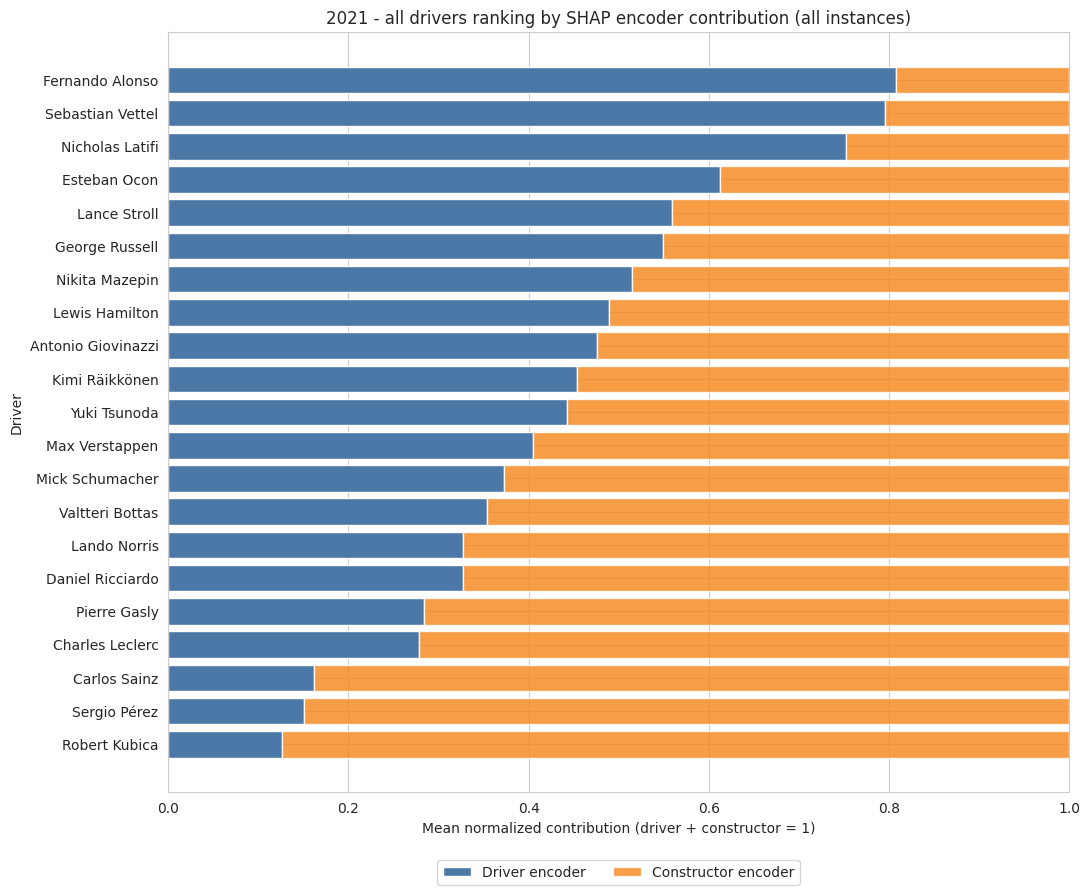

In [9]:
# ---------------------------------------------------------------------------
# Visualization: all drivers in 2021 (all instances)
# ---------------------------------------------------------------------------
plot_all_df = rank_driver_all.copy().iloc[::-1]
y_all = np.arange(len(plot_all_df))

plt.figure(figsize=(11, 9))
plt.barh(
    y_all,
    plot_all_df["mean_driver_importance"],
    label="Driver encoder",
    color="#4C78A8",
)
plt.barh(
    y_all,
    plot_all_df["mean_constructor_importance"],
    left=plot_all_df["mean_driver_importance"],
    label="Constructor encoder",
    alpha=0.8,
    color="#F58518",
)

plt.title(f"{YEAR} - all drivers ranking by SHAP encoder contribution (all instances)")
plt.xlabel("Mean normalized contribution (driver + constructor = 1)")
plt.ylabel("Driver")
plt.yticks(y_all, plot_all_df["driver_name"])
plt.xlim(0, 1)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

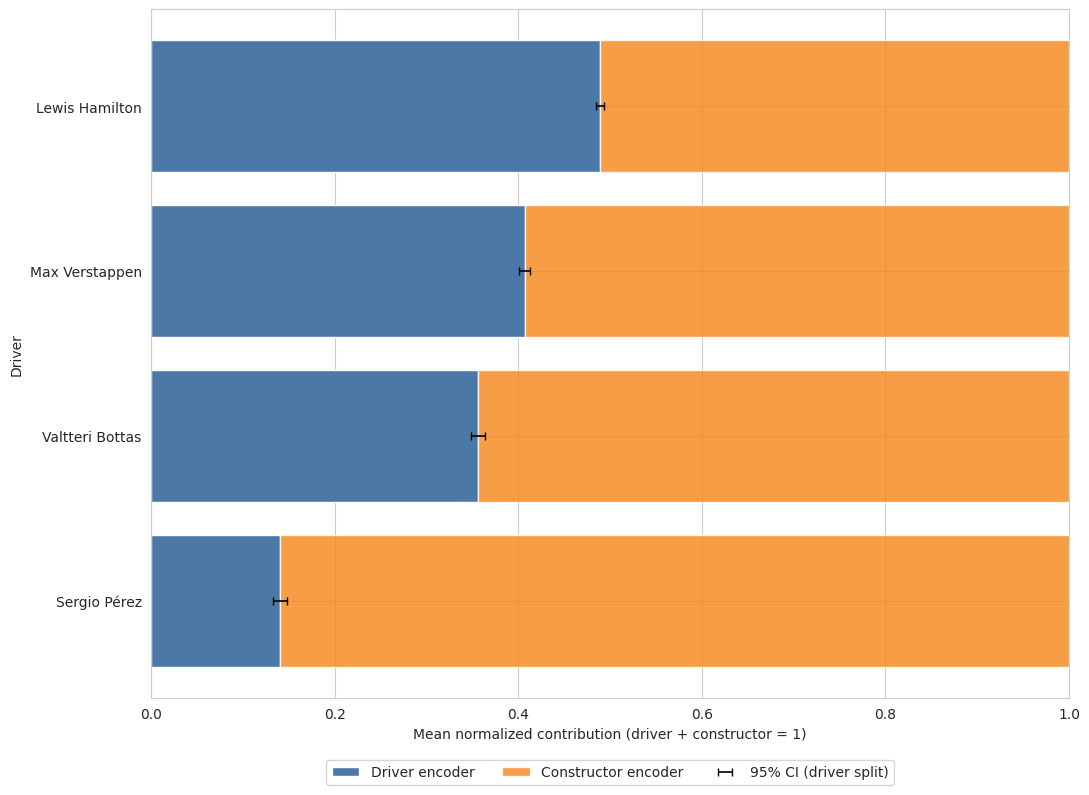

In [10]:
# ---------------------------------------------------------------------------
# Visualization: positive-only ranking (top drivers) + 95% CI
# ---------------------------------------------------------------------------
plot_df = rank_driver_positive.head(TOP_K).copy().iloc[::-1]
y_pos = np.arange(len(plot_df))

plt.figure(figsize=(11, 8))
plt.barh(
    y_pos,
    plot_df["mean_driver_importance_positive"],
    label="Driver encoder",
    color="#4C78A8",
)
plt.barh(
    y_pos,
    plot_df["mean_constructor_importance_positive"],
    left=plot_df["mean_driver_importance_positive"],
    label="Constructor encoder",
    alpha=0.8,
    color="#F58518",
)

# Place 95% CI exactly at the transition point between driver and constructor segments.
x_center = plot_df["mean_driver_importance_positive"].values
xerr_left = x_center - plot_df["driver_ci95_low_positive"].values
xerr_right = plot_df["driver_ci95_high_positive"].values - x_center
plt.errorbar(
    x=x_center,
    y=y_pos,
    xerr=[xerr_left, xerr_right],
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=3,
    label="95% CI (driver split)",
)

# plt.title(
  #  f"{YEAR} Positive-only (top3=1) - driver importance ranking (top {TOP_K}, min {MIN_POSITIVE_RACES} races)"
# )
plt.xlabel("Mean normalized contribution (driver + constructor = 1)")
plt.ylabel("Driver")
plt.yticks(y_pos, plot_df["driver_name"])
plt.xlim(0, 1)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

In [11]:
# Optional: save detailed outputs
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

analysis_df.to_csv(f"{OUTPUT_DIR}/shap_encoder_importance_instances_{YEAR}.csv", index=False)
per_driver.to_csv(f"{OUTPUT_DIR}/shap_encoder_importance_driver_rank_{YEAR}.csv", index=False)
positive_df.to_csv(f"{OUTPUT_DIR}/shap_encoder_importance_instances_{YEAR}_positive_only.csv", index=False)
rank_driver_positive.to_csv(
    f"{OUTPUT_DIR}/shap_encoder_importance_driver_rank_{YEAR}_positive_only_with_threshold{MIN_POSITIVE_RACES}.csv",
    index=False,
)
rank_driver_positive.to_csv(
    f"{OUTPUT_DIR}/shap_encoder_importance_driver_rank_{YEAR}_positive_only.csv",
    index=False,
)
print("Saved CSV files in notebooks/output/")

Saved CSV files in notebooks/output/


In [12]:
# ---------------------------------------------------------------------------
# Validation checks for signed SHAP interpretation
# ---------------------------------------------------------------------------
analysis_df["driver_sign_group"] = np.where(
    analysis_df["driver_signed"] >= 0,
    "driver_signed_positive",
    "driver_signed_negative",
)
analysis_df["constructor_sign_group"] = np.where(
    analysis_df["constructor_signed"] >= 0,
    "constructor_signed_positive",
    "constructor_signed_negative",
)

sign_group_summary = (
    analysis_df
    .groupby("driver_sign_group", as_index=False)
    .agg(
        n=("raceId", "count"),
        mean_driver_signed=("driver_signed", "mean"),
        mean_driver_delta_prob=("driver_delta_prob", "mean"),
    )
)

constructor_sign_group_summary = (
    analysis_df
    .groupby("constructor_sign_group", as_index=False)
    .agg(
        n=("raceId", "count"),
        mean_constructor_signed=("constructor_signed", "mean"),
        mean_constructor_delta_prob=("constructor_delta_prob", "mean"),
    )
)

driver_corr = np.corrcoef(analysis_df["driver_signed"], analysis_df["driver_delta_prob"])[0, 1]
constructor_corr = np.corrcoef(analysis_df["constructor_signed"], analysis_df["constructor_delta_prob"])[0, 1]

print("Driver sign-group sanity:")
display(sign_group_summary)
print("Constructor sign-group sanity:")
display(constructor_sign_group_summary)
print(f"Corr(driver_signed, driver_delta_prob): {driver_corr:.4f}")
print(f"Corr(constructor_signed, constructor_delta_prob): {constructor_corr:.4f}")

Driver sign-group sanity:


,driver_sign_group,n,mean_driver_signed,mean_driver_delta_prob
0,driver_signed_negative,221,-0.980007,-0.019503
1,driver_signed_positive,219,1.088058,0.162252


Constructor sign-group sanity:


,constructor_sign_group,n,mean_constructor_signed,mean_constructor_delta_prob
0,constructor_signed_negative,262,-0.965798,-0.026957
1,constructor_signed_positive,178,1.751514,0.280431


Corr(driver_signed, driver_delta_prob): 0.8004
Corr(constructor_signed, constructor_delta_prob): 0.9050


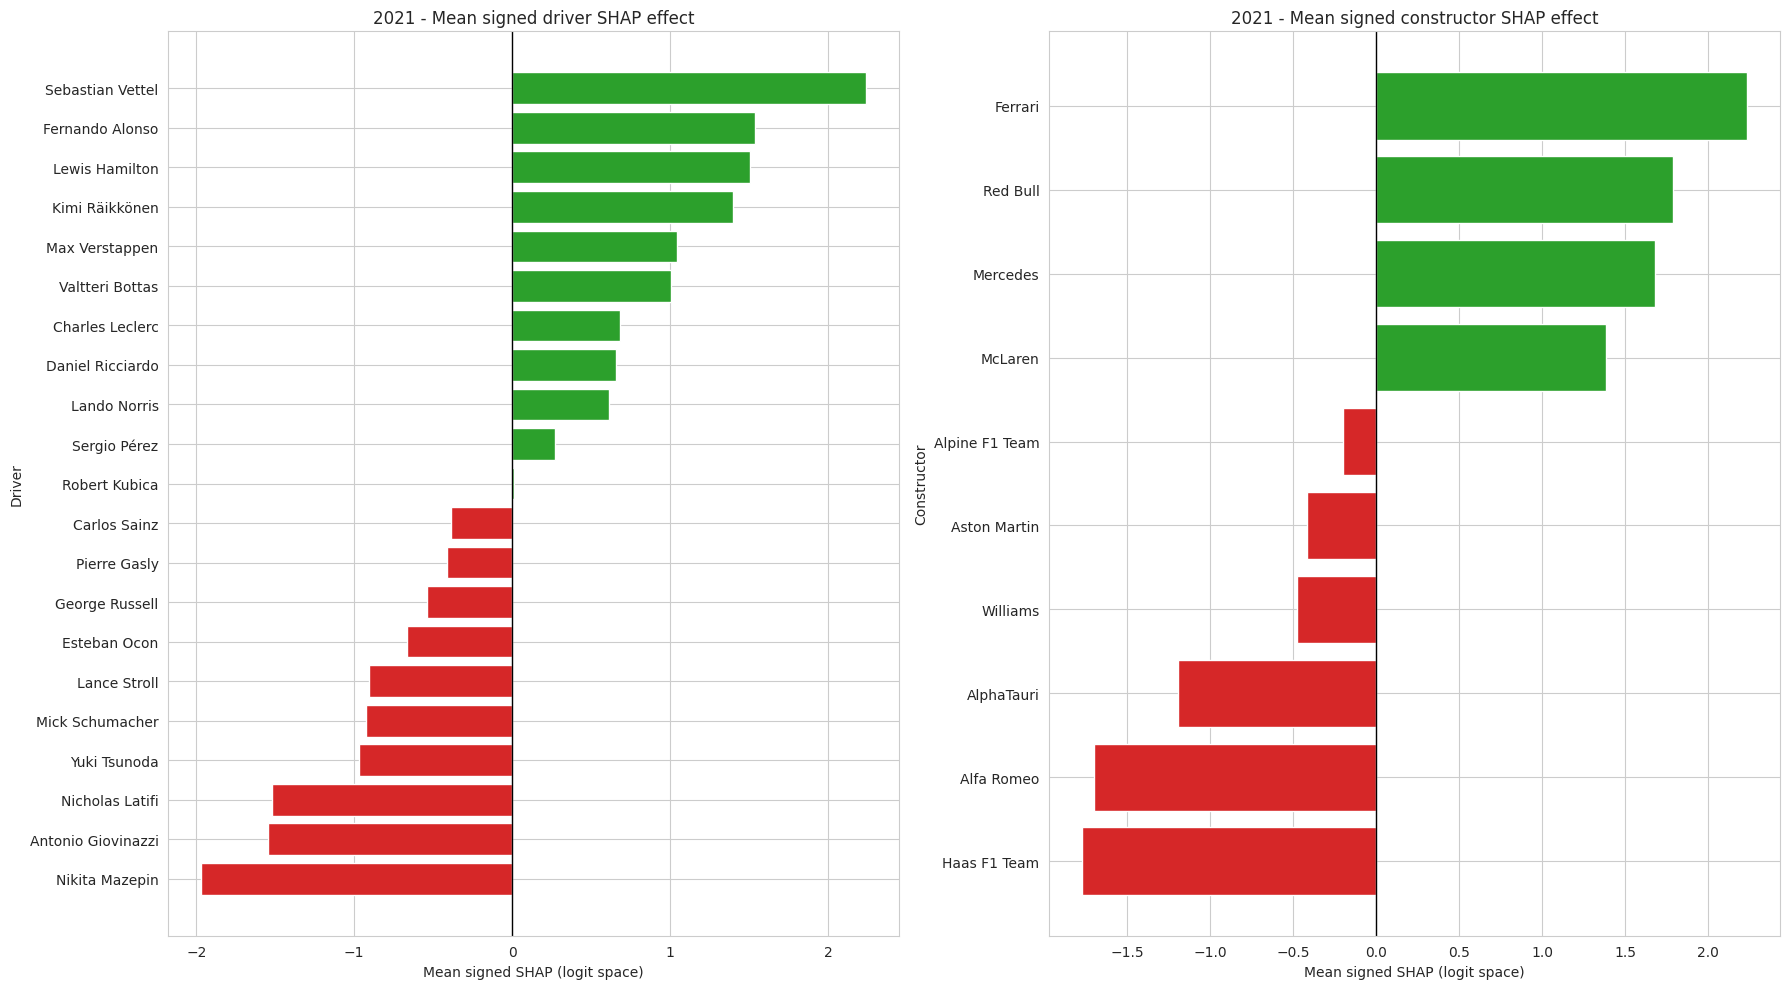

Top drivers by positive probability delta from driver encoder:


,driverId,driver_name,races,mean_prediction_prob_top3,mean_driver_importance,mean_constructor_importance,mean_driver_signed,mean_constructor_signed,mean_driver_delta_prob,mean_constructor_delta_prob
0,0,Lewis Hamilton,22,0.526051,0.489331,0.510669,1.503922,1.517523,0.326869,0.329278
4,19,Sebastian Vettel,22,0.260453,0.795960,0.204040,2.239444,-0.322980,0.232308,-0.066987
8,821,Valtteri Bottas,22,0.487717,0.353837,0.646163,1.008446,1.841243,0.228398,0.353805
9,829,Max Verstappen,22,0.459262,0.405032,0.594968,1.044595,1.657465,0.225244,0.313238
14,842,Charles Leclerc,22,0.453661,0.278157,0.721843,0.681337,2.091753,0.159075,0.367593
1,3,Fernando Alonso,22,0.182135,0.807560,0.192440,1.540210,-0.156923,0.133967,-0.023296
7,816,Daniel Ricciardo,22,0.298375,0.327218,0.672782,0.658377,1.393856,0.117730,0.202395
15,844,Lando Norris,22,0.288398,0.327453,0.672547,0.613057,1.379455,0.107708,0.194064
6,814,Sergio Pérez,22,0.325442,0.150415,0.849585,0.269235,1.917376,0.056604,0.260010
2,7,Kimi Räikkönen,20,0.040515,0.454119,0.545881,1.396845,-1.666584,0.029937,-0.139764


Top constructors by positive probability delta from constructor encoder:


,constructorId,constructor_name,races,mean_prediction_prob_top3,mean_driver_importance,mean_constructor_importance,mean_driver_signed,mean_constructor_signed,mean_driver_delta_prob,mean_constructor_delta_prob
6,129,Mercedes,44,0.506884,0.421584,0.578416,1.256184,1.679383,0.277634,0.341542
2,5,Ferrari,44,0.368509,0.219898,0.780102,0.147346,2.231470,0.037871,0.307952
3,8,Red Bull,44,0.392352,0.277723,0.722277,0.656915,1.787421,0.140924,0.286624
0,0,McLaren,44,0.293387,0.327336,0.672664,0.635717,1.386655,0.112719,0.198230
1,2,Williams,44,0.013604,0.650601,0.349399,-1.029350,-0.473988,-0.019222,-0.007662
7,207,Haas F1 Team,44,0.002431,0.443557,0.556443,-1.447862,-1.767990,-0.006679,-0.011718
9,210,Alpine F1 Team,44,0.101500,0.710255,0.289745,0.436439,-0.199325,0.057312,-0.014395
8,209,AlphaTauri,44,0.008192,0.363462,0.636538,-0.692348,-1.193317,-0.007672,-0.018826
5,115,Aston Martin,44,0.136413,0.677337,0.322663,0.666932,-0.414663,0.106850,-0.037644
4,49,Alfa Romeo,44,0.019816,0.450130,0.549870,-0.136723,-1.700862,0.009878,-0.070146


In [13]:
# ---------------------------------------------------------------------------
# Sign-preserving visualization: drivers and constructors
# ---------------------------------------------------------------------------
plot_signed_driver = per_driver.sort_values("mean_driver_signed", ascending=True).copy()
plot_signed_constructor = per_constructor.sort_values("mean_constructor_signed", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=False)

colors_driver = ["#d62728" if v < 0 else "#2ca02c" for v in plot_signed_driver["mean_driver_signed"]]
axes[0].barh(plot_signed_driver["driver_name"], plot_signed_driver["mean_driver_signed"], color=colors_driver)
axes[0].axvline(0.0, color="black", linewidth=1)
axes[0].set_title(f"{YEAR} - Mean signed driver SHAP effect")
axes[0].set_xlabel("Mean signed SHAP (logit space)")
axes[0].set_ylabel("Driver")

colors_constructor = ["#d62728" if v < 0 else "#2ca02c" for v in plot_signed_constructor["mean_constructor_signed"]]
axes[1].barh(plot_signed_constructor["constructor_name"], plot_signed_constructor["mean_constructor_signed"], color=colors_constructor)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set_title(f"{YEAR} - Mean signed constructor SHAP effect")
axes[1].set_xlabel("Mean signed SHAP (logit space)")
axes[1].set_ylabel("Constructor")

plt.tight_layout()
plt.show()

print("Top drivers by positive probability delta from driver encoder:")
display(per_driver.sort_values("mean_driver_delta_prob", ascending=False).head(10))
print("Top constructors by positive probability delta from constructor encoder:")
display(per_constructor.sort_values("mean_constructor_delta_prob", ascending=False).head(10))

In [14]:
# ---------------------------------------------------------------------------
# Extended exports: magnitude and directional SHAP views
# ---------------------------------------------------------------------------
OUTPUT_DIR_SIGNED = "../output"
os.makedirs(OUTPUT_DIR_SIGNED, exist_ok=True)

analysis_df.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_instance_level_{YEAR}_signed.csv",
    index=False,
)
per_driver.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_driver_rank_{YEAR}_dual_view.csv",
    index=False,
)
per_constructor.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_constructor_rank_{YEAR}_dual_view.csv",
    index=False,
)
rank_driver_signed_positive.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_driver_signed_positive_{YEAR}.csv",
    index=False,
)
rank_driver_signed_negative.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_driver_signed_negative_{YEAR}.csv",
    index=False,
)
rank_constructor_signed_positive.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_constructor_signed_positive_{YEAR}.csv",
    index=False,
)
rank_constructor_signed_negative.to_csv(
    f"{OUTPUT_DIR_SIGNED}/shap_encoder_constructor_signed_negative_{YEAR}.csv",
    index=False,
)

print("Saved signed + magnitude SHAP outputs:")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_instance_level_{YEAR}_signed.csv")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_driver_rank_{YEAR}_dual_view.csv")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_constructor_rank_{YEAR}_dual_view.csv")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_driver_signed_positive_{YEAR}.csv")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_driver_signed_negative_{YEAR}.csv")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_constructor_signed_positive_{YEAR}.csv")
print(f"- {OUTPUT_DIR_SIGNED}/shap_encoder_constructor_signed_negative_{YEAR}.csv")

Saved signed + magnitude SHAP outputs:
- ../output/shap_encoder_instance_level_2021_signed.csv
- ../output/shap_encoder_driver_rank_2021_dual_view.csv
- ../output/shap_encoder_constructor_rank_2021_dual_view.csv
- ../output/shap_encoder_driver_signed_positive_2021.csv
- ../output/shap_encoder_driver_signed_negative_2021.csv
- ../output/shap_encoder_constructor_signed_positive_2021.csv
- ../output/shap_encoder_constructor_signed_negative_2021.csv
